# Reproducing Kallenberg et al. (2023): Nitrogen management in winter wheat

This notebook reproduces the NASA-POWER-driven experiment from:

> Kallenberg, M. G. J., Overweg, H., van Bree, R., & Athanasiadis, I. N. (2023).
> Nitrogen management with reinforcement learning and crop growth models.
> *Environmental Data Science*, 2, e34. https://doi.org/10.1017/eds.2023.28

(see `Paper-Cropgym.pdf` in this folder). It
trains a PPO agent on the exact winter-wheat LINTUL3 dataset in
[`lintul3_gym/envs/data/winterwheat`](../../lintul3_gym/envs/data/winterwheat) (NASA POWER weather, three Dutch training
locations, odd training years 1990-2021) and evaluates it against the paper's **Standard Practice**
(SP) baseline on held-out even years, in both the Northern (Netherlands, in-distribution) and
Southern (France, out-of-distribution) climates.

**Scope and caveats** -- see [`lintul3_gym/envs/data/winterwheat/README.md`](../../lintul3_gym/envs/data/winterwheat/README.md)
for the full discussion:

- **No Ceres agent.** Ceres optimizes a per-episode nitrogen dose with access to the *entire*
  season's future weather; it is not implemented here. Every comparison below is Standard Practice
  vs. RL only.
- **Reduced training seeds.** The paper trains 15 independently-seeded RL runs per configuration to
  report a median + IQR band; this notebook trains `N_SEEDS = 3` for tractable notebook runtime.
  The resulting band is a coarser estimate of RL variability than the paper's.
- **Model fidelity.** This project depends on stock `pcse==6.0.13`, not the patched fork the
  paper's exact numbers were produced with (see `lintul3_gym/envs/data/winterwheat/pcse-lintul3.patch`).
  Three calibrated parameters (`FRTRL`, `RTMIN`, `TNSOILI`) have no effect here, so expect similar,
  not identical, numbers to the paper's Tables 2/3.
- **Standard Practice timing.** SP applies a fixed, pre-optimized total nitrogen dose across the
  paper's three real fertilization dates (Feb 24, Mar 26, Apr 29 -- from the reference
  implementation's `pcse_gym/utils/eval.py`), split evenly. The paper's own code instead applies
  that total as a single early dose when computing its published numbers (a documented LINTUL3
  leaching-model shortcut); using the literal three dates here means SP's yield/reward will not
  exactly match Table 2/3 either.


## Setup Environment

In [ ]:
# %pip install lintul3-gym==0.1.0 --quiet
# %pip install gymnasium==1.3.0 numpy==2.3.0 pcse==6.0.13 --quiet
# %pip install stable-baselines3==2.9.0 matplotlib==3.11.0 pytest==8.4.2 sphinx==8.2.3 --quiet

In [11]:
# print version of installed packages
import lintul3_gym
print(f"Lintul3-Gym version: {lintul3_gym.__version__}")
import gymnasium as gym
print(f"Gymnasium version: {gym.__version__}")
import numpy as np
print(f"Numpy version: {np.__version__}")
import pcse
print(f"PCSE version: {pcse.__version__}")
import stable_baselines3 as sb3
print(f"Stable Baselines3 version: {sb3.__version__}")
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")

# Experiment was performed using the following versions of the packages:
# Gymnasium version: 1.2.3
# Numpy version: 2.3.3
# PCSE version: 6.0.13
# Stable Baselines3 version: 2.9.0
# Matplotlib version: 3.11.0

Lintul3-Gym version: 0.1.0
Gymnasium version: 1.3.0
Numpy version: 2.3.0
PCSE version: 6.0.13
Stable Baselines3 version: 2.9.0
Matplotlib version: 3.11.0


In [1]:
from __future__ import annotations

import sys
from datetime import date
from pathlib import Path

import numpy as np

# This notebook lives in examples/nitrogen-winterwheat/, two levels below the repo root.
# Only needed to make a local repo checkout importable if lintul3_gym isn't pip-installed;
# the bundled data directory itself is resolved via bundled_data_dir() below, not by path.
cwd = Path.cwd()
repo_root = cwd.parent.parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

In [3]:
from lintul3_gym.envs.environment import bundled_data_dir

# Same bundled_data_dir(name) helper used by the spring-wheat tutorial notebook
# (examples/nitrogen-springwheat/Tutorial-Lintul3gym.ipynb), just a different bundled dataset name.
data_dir = bundled_data_dir("winterwheat")
print(f"Winter-wheat data dir: {data_dir}")
print(f"Files in data dir: {sorted(p.name for p in data_dir.iterdir())}")

Winter-wheat data dir: C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\winterwheat
Files in data dir: ['README.md', 'lintul3_winterwheat.agro', 'lintul3_winterwheat.crop', 'lintul3_winterwheat.site', 'lintul3_winterwheat.soil', 'pcse-lintul3.patch']


In [4]:
# Optional: silence a Windows-only PCSE logging quirk. Importing pcse installs a shared
# root-logger RotatingFileHandler at ~/.pcse/logs/pcse.log; on Windows its log-rotation
# rename can fail with a PermissionError if another process (e.g. a second Jupyter kernel)
# still has that file open, printing a harmless but noisy "--- Logging error ---" banner.
# This swaps it for a plain, non-rotating handler so that rename is never attempted.
# Purely cosmetic either way -- remove this cell if you'd rather see PCSE's logging as-is.
from lintul3_gym import silence_pcse_log_rotation

silence_pcse_log_rotation()

## Configuration

Locations, years, crop calendar, and hyperparameters below match the paper's use case
(`pcse_gym/utils/defaults.py` and `train_winterwheat.py` in
[WUR-AI/PCSE-Gym](https://github.com/WUR-AI/PCSE-Gym)), except `N_SEEDS` (see the scope note above).

In [5]:
from lintul3_gym import Lintul3Env, RewardConfig, SeasonConfig, WeatherConfig
from lintul3_gym.policies import (
    StandardPracticePolicy,
    ZeroNitrogenPolicy,
    evaluate_policy,
    evaluate_policy_over_weather,
    evaluate_sb3_policy,
)
from lintul3_gym.sb3 import make_eval_env, make_training_env
from lintul3_gym.viz import plot_complete_comparison_monthly, plot_nitrogen_vs_rainfall
from stable_baselines3 import PPO

# Winter wheat "emerges" (already growing) on Jan 1 and reaches earliest maturity by Sep 1 of the
# same year -- see lintul3_gym/envs/data/winterwheat/lintul3_winterwheat.agro.
WINTERWHEAT_SEASON = SeasonConfig(
    campaign_start=date(2007, 1, 1),
    crop_start=date(2007, 1, 1),
    crop_end=date(2007, 9, 1),
    crop_name="winter-wheat",
    crop_start_type="emergence",
    crop_end_type="earliest",
    max_duration=365,
)

# Paper's training locations (Netherlands) and held-out test locations (Netherlands + France).
TRAIN_LOCATIONS = ((52.0, 5.5), (51.5, 5.0), (52.5, 6.0))
TEST_LOCATION_NORTH = (52.0, 5.5)  # in-distribution climate (Netherlands)
TEST_LOCATION_SOUTH = (48.0, 0.0)  # out-of-distribution climate (France)

ALL_YEARS = tuple(range(1990, 2022))
TRAIN_YEARS = tuple(year for year in ALL_YEARS if year % 2 == 1)  # 1991-2021, 16 years
TEST_YEARS = tuple(year for year in ALL_YEARS if year % 2 == 0)   # 1990-2020, 16 years

COSTS_NITROGEN = 10.0  # paper's beta=10.0 (emphasizes environmental cost over pure economics)
N_SEEDS = 3            # paper trains 15 seeds; reduced here for notebook runtime (see intro)
N_TRAIN_STEPS = 400_000

print(f"Train years ({len(TRAIN_YEARS)}): {TRAIN_YEARS}")
print(f"Test years ({len(TEST_YEARS)}): {TEST_YEARS}")

Train years (16): (1991, 1993, 1995, 1997, 1999, 2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021)
Test years (16): (1990, 1992, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020)


## Build the training environment

In [6]:
train_environment = Lintul3Env(
    data_dir=data_dir,
    season=WINTERWHEAT_SEASON,
    decision_interval=7,
    reward=RewardConfig(nitrogen_cost=COSTS_NITROGEN),
    weather=WeatherConfig(
        source="nasa",
        locations=TRAIN_LOCATIONS,
        years=TRAIN_YEARS,
        random_weather_per_episode=True,
    ),
)
train_environment.reset(seed=0)
print(f"Action space: {train_environment.action_space}")
print(f"Observation space: {train_environment.observation_space}")

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\winterwheat: crop, site, soil
Action space: Box(0.0, 20.0, (1,), float32)
Observation space: Dict('crop': Box(-inf, inf, (9,), float32), 'management': Box(0.0, inf, (2,), float32), 'weather': Box(-inf, inf, (4,), float32))


### Quick baseline preview (one training-distribution episode)

In [7]:
sp_preview = evaluate_policy(train_environment, StandardPracticePolicy(), seed=4)
zero_preview = evaluate_policy(train_environment, ZeroNitrogenPolicy(), seed=4)
print(f"Standard Practice: reward={sp_preview.total_reward:.2f}, WSO={sp_preview.final_wso:.2f}, N={sp_preview.total_nitrogen:.2f} g/m2")
print(f"Zero N:            reward={zero_preview.total_reward:.2f}, WSO={zero_preview.final_wso:.2f}, N={zero_preview.total_nitrogen:.2f} g/m2")

Standard Practice: reward=116.79, WSO=409.33, N=17.07 g/m2
Zero N:            reward=0.00, WSO=121.84, N=0.00 g/m2


## Train `N_SEEDS` independently-seeded PPO agents

Each seed trains for `N_TRAIN_STEPS` (400,000) timesteps on the *training* distribution (odd
years, three Dutch locations, one random `(location, year)` per episode). This is the expensive
cell in the notebook -- runtime scales linearly with `N_SEEDS`.

In [ ]:
seed_artifacts = []
for seed in range(N_SEEDS):
    seed_train_env = make_training_env(train_environment, log_dir=f"./logs/seed_{seed}/")
    model = PPO("MlpPolicy", seed_train_env, seed=seed, verbose=0)
    model.learn(N_TRAIN_STEPS)

    model_path = f"ppo_winterwheat_seed_{seed}"
    stats_path = f"vec_normalize_stats_seed_{seed}.pkl"
    model.save(model_path)
    seed_train_env.save(stats_path)
    seed_artifacts.append((model_path, stats_path))
    print(f"seed {seed}: trained {N_TRAIN_STEPS} steps -> {model_path}.zip, {stats_path}")

## Northern-climate evaluation (held-out even test years, Netherlands)

`test_environment_north` reuses the training location shape but cycles deterministically
(`random_weather_per_episode=False`) through the disjoint, held-out even-year set, so every
`reset()` advances to the next year in the same order for every policy -- Standard Practice,
Zero N, and each RL seed all see the same 16 test years lined up one-to-one.

In [8]:
test_environment_north = Lintul3Env(
    data_dir=data_dir,
    season=WINTERWHEAT_SEASON,
    decision_interval=7,
    reward=RewardConfig(nitrogen_cost=COSTS_NITROGEN),
    weather=WeatherConfig(
        source="nasa",
        locations=(TEST_LOCATION_NORTH,),
        years=TEST_YEARS,
        random_weather_per_episode=False,
    ),
)
n_test_years = len(TEST_YEARS)

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\winterwheat: crop, site, soil


In [9]:
sp_results_north = evaluate_policy_over_weather(test_environment_north, StandardPracticePolicy())
zero_results_north = evaluate_policy_over_weather(test_environment_north, ZeroNitrogenPolicy())

In [19]:
# Rebuild the seed_artifacts list since the model and stats files were already saved above.
seed_artifacts = []
for seed in range(N_SEEDS):
    model_path = f"ppo_winterwheat_seed_{seed}"
    stats_path = f"vec_normalize_stats_seed_{seed}.pkl"
    seed_artifacts.append((model_path, stats_path))
    print(f"seed {seed}: model={model_path}.zip, stats={stats_path}")

seed 0: model=ppo_winterwheat_seed_0.zip, stats=vec_normalize_stats_seed_0.pkl
seed 1: model=ppo_winterwheat_seed_1.zip, stats=vec_normalize_stats_seed_1.pkl
seed 2: model=ppo_winterwheat_seed_2.zip, stats=vec_normalize_stats_seed_2.pkl


In [ ]:
# Evaluate each of the trained seeds on the held-out test environment (Netherlands).
rl_results_north = []
for model_path, stats_path in seed_artifacts:
    eval_env = make_eval_env(test_environment_north, stats_path)
    model = PPO.load(model_path, env=eval_env)
    rl_results_north.append(evaluate_sb3_policy(eval_env, model, n_episodes=n_test_years))

### Numeric summary (median + IQR across the 16 test years)

In [13]:
def summarize(results, label):
    rewards = np.array([r.total_reward for r in results])
    nitrogen = np.array([r.total_nitrogen for r in results])
    yields = np.array([r.final_wso for r in results])
    print(
        f"{label:24s} reward={np.median(rewards):7.2f} "
        f"(IQR {np.percentile(rewards, 25):.2f}-{np.percentile(rewards, 75):.2f})   "
        f"N={np.median(nitrogen):6.2f} g/m2   WSO={np.median(yields):7.2f} g/m2"
    )

In [14]:
print("Northern climate (Netherlands), n=16 test years")
summarize(zero_results_north, "Zero N")
summarize(sp_results_north, "Standard Practice")
for seed, results in enumerate(rl_results_north):
    summarize(results, f"RL (seed {seed})")
pooled_rl_north = [r for results in rl_results_north for r in results]
summarize(pooled_rl_north, "RL (all seeds pooled)")

Northern climate (Netherlands), n=16 test years
Zero N                   reward=   0.00 (IQR 0.00-0.00)   N=  0.00 g/m2   WSO= 155.35 g/m2
Standard Practice        reward= 190.98 (IQR 164.67-226.07)   N= 17.07 g/m2   WSO= 514.44 g/m2
RL (seed 0)              reward= 266.99 (IQR 202.32-301.30)   N= 30.00 g/m2   WSO= 706.86 g/m2
RL (seed 1)              reward= 265.12 (IQR 208.14-306.71)   N= 28.00 g/m2   WSO= 691.98 g/m2
RL (seed 2)              reward= 255.28 (IQR 203.02-279.57)   N= 31.00 g/m2   WSO= 714.48 g/m2
RL (all seeds pooled)    reward= 260.88 (IQR 206.93-300.89)   N= 30.00 g/m2   WSO= 703.12 g/m2


## Southern-climate out-of-distribution evaluation (France, not retrained)

Reuses the *same* trained SP policy and the *same* `N_SEEDS` RL model artifacts against French
weather (48N, 0E) -- matching the paper's climate-resilience test, where SP and RL are evaluated
on new weather rather than retrained (only Ceres is re-tuned per climate, and Ceres is excluded
here).

In [15]:
test_environment_south = Lintul3Env(
    data_dir=data_dir,
    season=WINTERWHEAT_SEASON,
    decision_interval=7,
    reward=RewardConfig(nitrogen_cost=COSTS_NITROGEN),
    weather=WeatherConfig(
        source="nasa",
        locations=(TEST_LOCATION_SOUTH,),
        years=TEST_YEARS,
        random_weather_per_episode=False,
    ),
)

sp_results_south = evaluate_policy_over_weather(test_environment_south, StandardPracticePolicy())
zero_results_south = evaluate_policy_over_weather(test_environment_south, ZeroNitrogenPolicy())

rl_results_south = []
for model_path, stats_path in seed_artifacts:
    eval_env = make_eval_env(test_environment_south, stats_path)
    model = PPO.load(model_path, env=eval_env)
    rl_results_south.append(evaluate_sb3_policy(eval_env, model, n_episodes=n_test_years))

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\winterwheat: crop, site, soil


In [16]:
print("Southern climate (France), n=16 test years")
summarize(zero_results_south, "Zero N")
summarize(sp_results_south, "Standard Practice")
for seed, results in enumerate(rl_results_south):
    summarize(results, f"RL (seed {seed})")
pooled_rl_south = [r for results in rl_results_south for r in results]
summarize(pooled_rl_south, "RL (all seeds pooled)")

Southern climate (France), n=16 test years
Zero N                   reward=   0.00 (IQR 0.00-0.00)   N=  0.00 g/m2   WSO= 136.00 g/m2
Standard Practice        reward= 168.57 (IQR 61.77-225.66)   N= 17.07 g/m2   WSO= 483.63 g/m2
RL (seed 0)              reward= 147.41 (IQR 28.41-258.82)   N= 26.00 g/m2   WSO= 469.04 g/m2
RL (seed 1)              reward= 223.86 (IQR 13.60-277.37)   N= 28.00 g/m2   WSO= 624.18 g/m2
RL (seed 2)              reward= 221.62 (IQR -2.12-290.14)   N= 28.00 g/m2   WSO= 656.85 g/m2
RL (all seeds pooled)    reward= 205.30 (IQR 21.18-275.14)   N= 28.00 g/m2   WSO= 611.13 g/m2


## Nitrogen applied vs. average daily rainfall (paper's Figure 4, Ceres omitted)

One point per test year: Standard Practice as a single dot, RL as a median+IQR error bar across
the `N_SEEDS` trained models, plus a hollow "median" marker and a linear trend line per series --
reproducing the two non-Ceres series from the paper's Figure 4 for both climates.

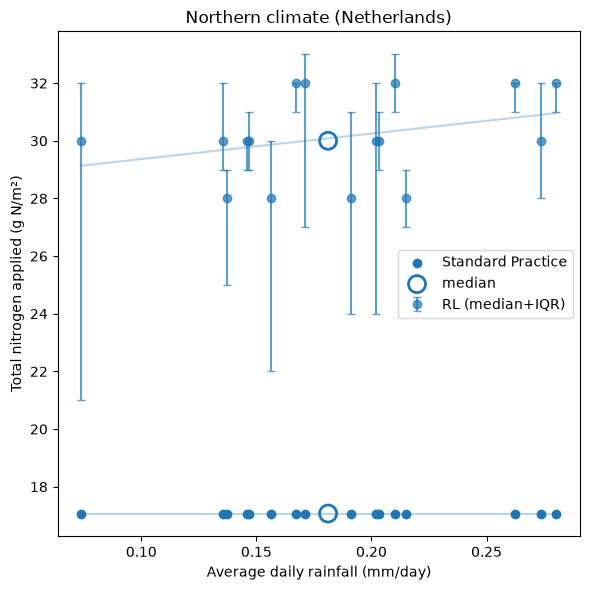

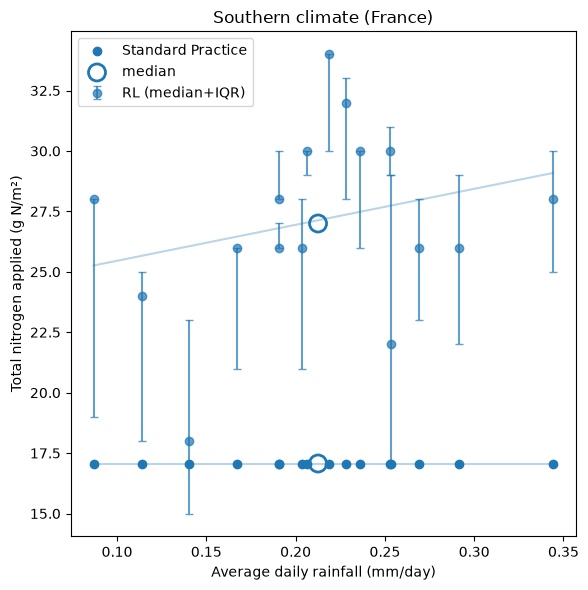

In [17]:
def average_daily_rainfall(result):
    return float(np.mean([record.weather["RAIN"] for record in result.history]))


def rainfall_vs_nitrogen_panel(sp_results, rl_results_per_seed, title):
    rainfall = [average_daily_rainfall(result) for result in sp_results]
    sp_nitrogen = [result.total_nitrogen for result in sp_results]
    rl_nitrogen_per_year = [
        [rl_results_per_seed[seed][year].total_nitrogen for seed in range(len(rl_results_per_seed))]
        for year in range(len(sp_results))
    ]
    plot_nitrogen_vs_rainfall(
        baseline_points={"Standard Practice": (rainfall, sp_nitrogen)},
        ensemble_points={"RL": (rainfall, rl_nitrogen_per_year)},
        title=title,
    )


rainfall_vs_nitrogen_panel(sp_results_north, rl_results_north, "Northern climate (Netherlands)")
rainfall_vs_nitrogen_panel(sp_results_south, rl_results_south, "Southern climate (France)")

## Seasonal dynamics: median + 95% interval by month (Northern climate)

Aligns all 16 test years by day-of-year to show *when* each policy applies nitrogen and how crop
state responds, complementing the yearly summaries above (RL shown for seed 0 only; see the
per-seed medians above for cross-seed spread).

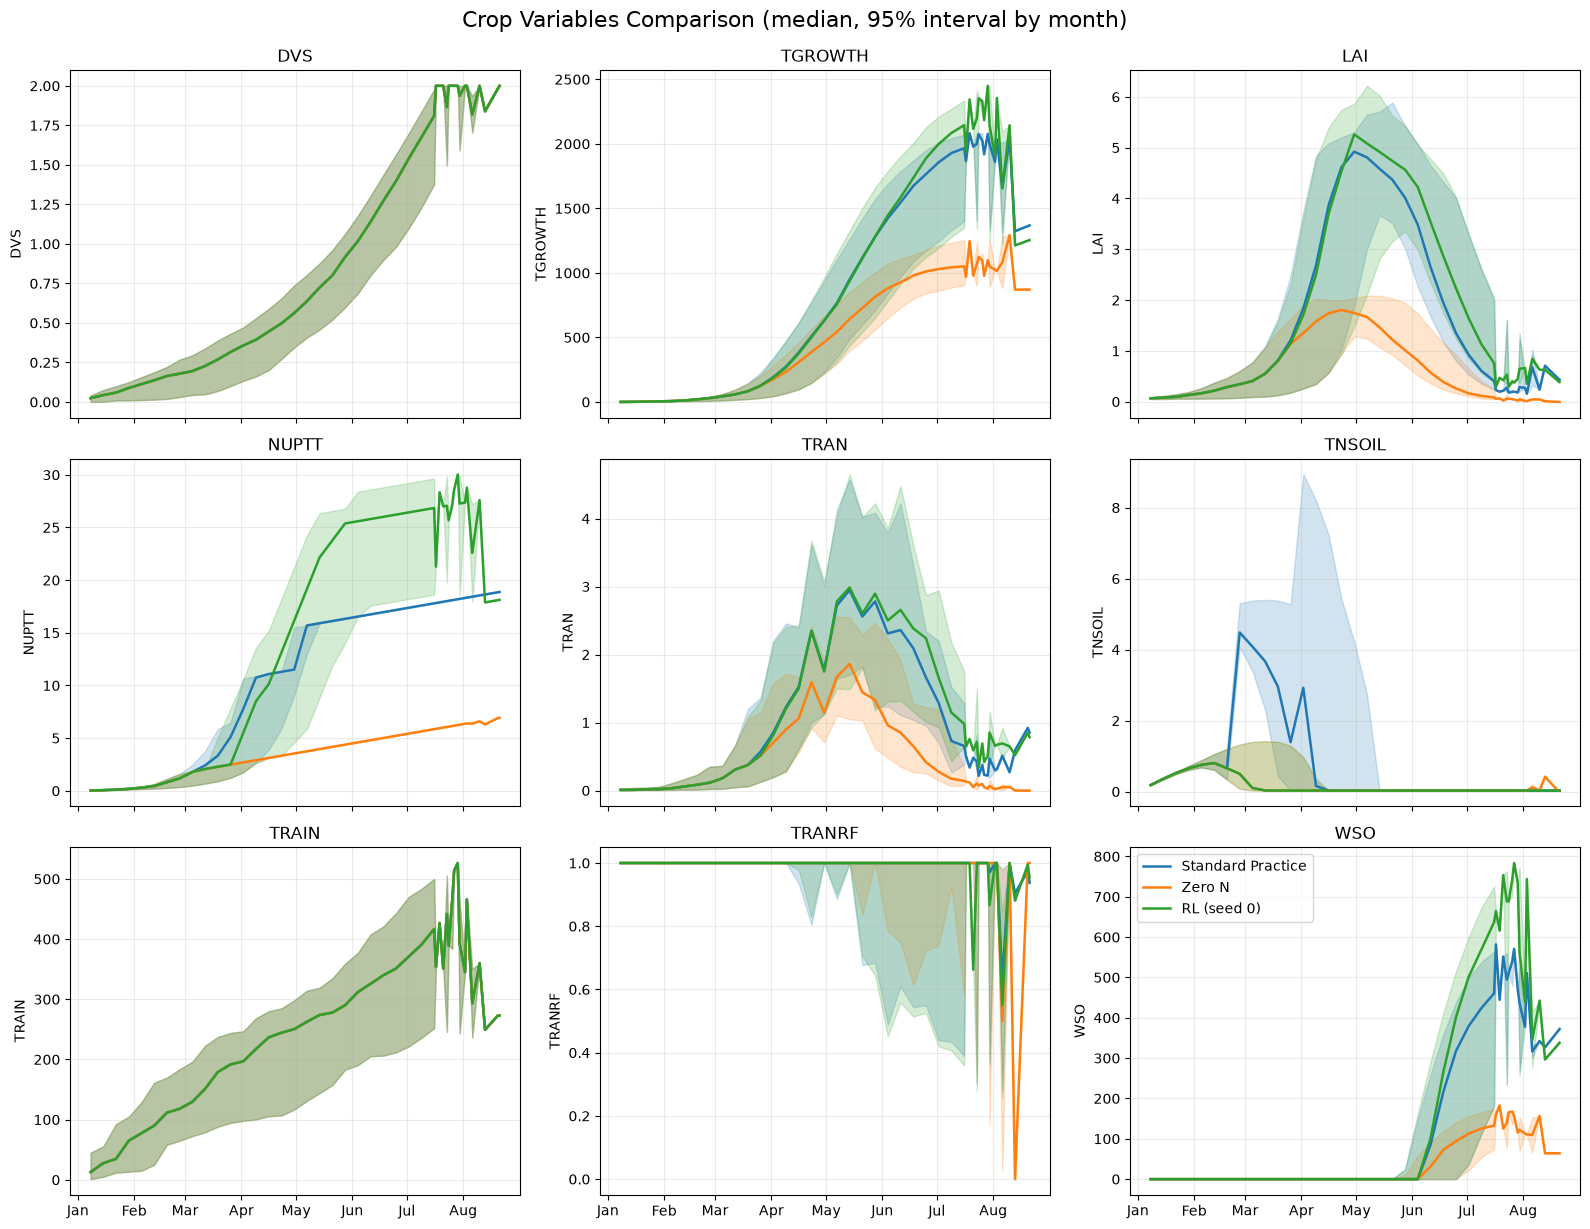

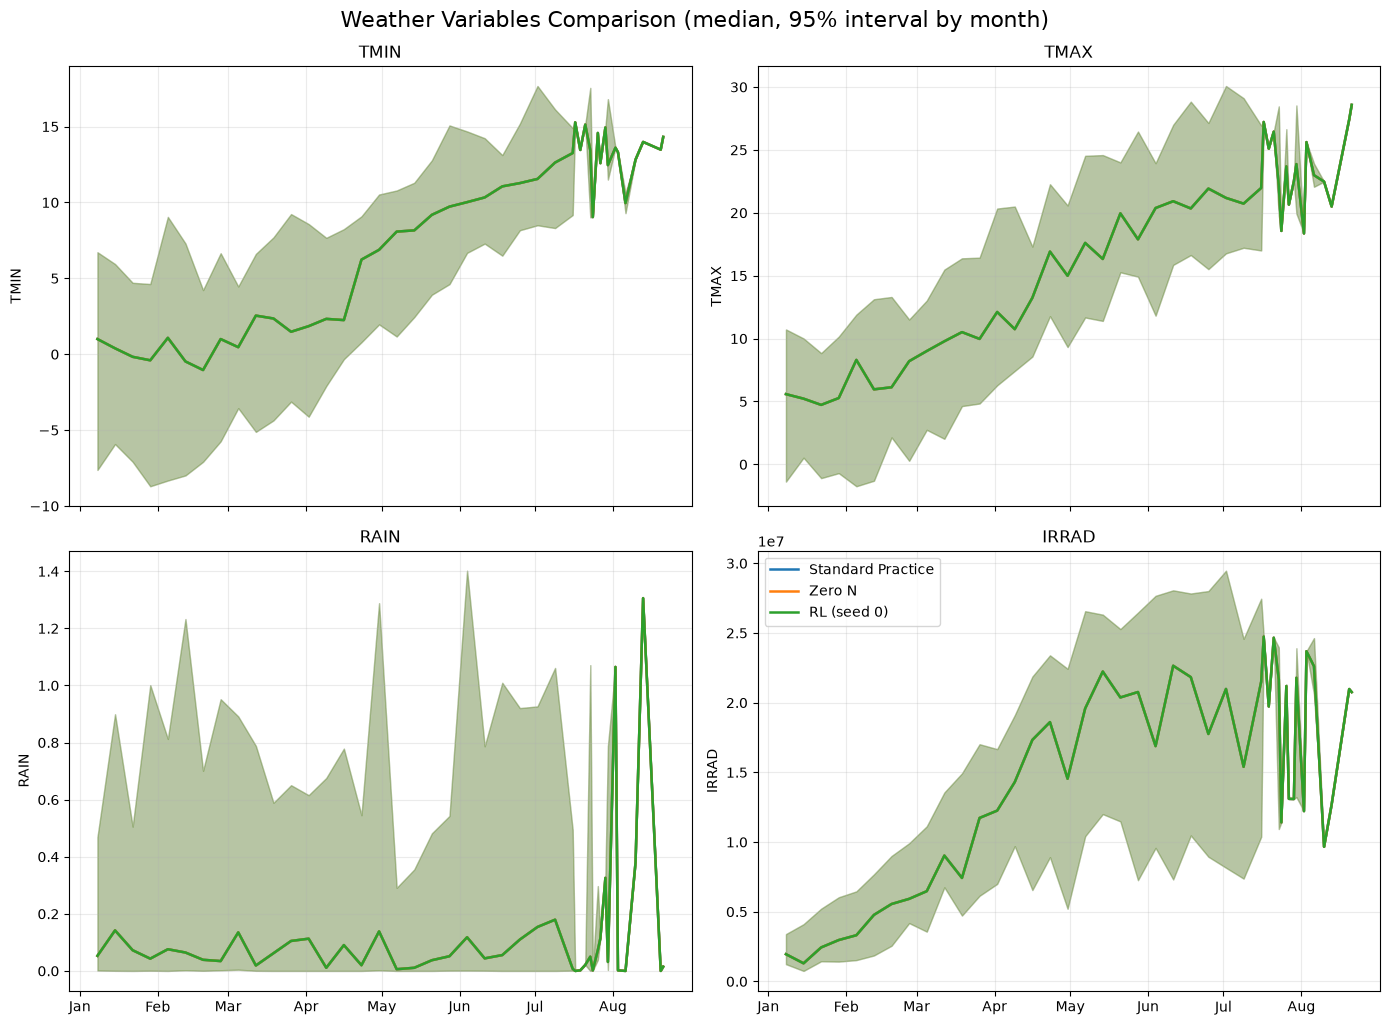

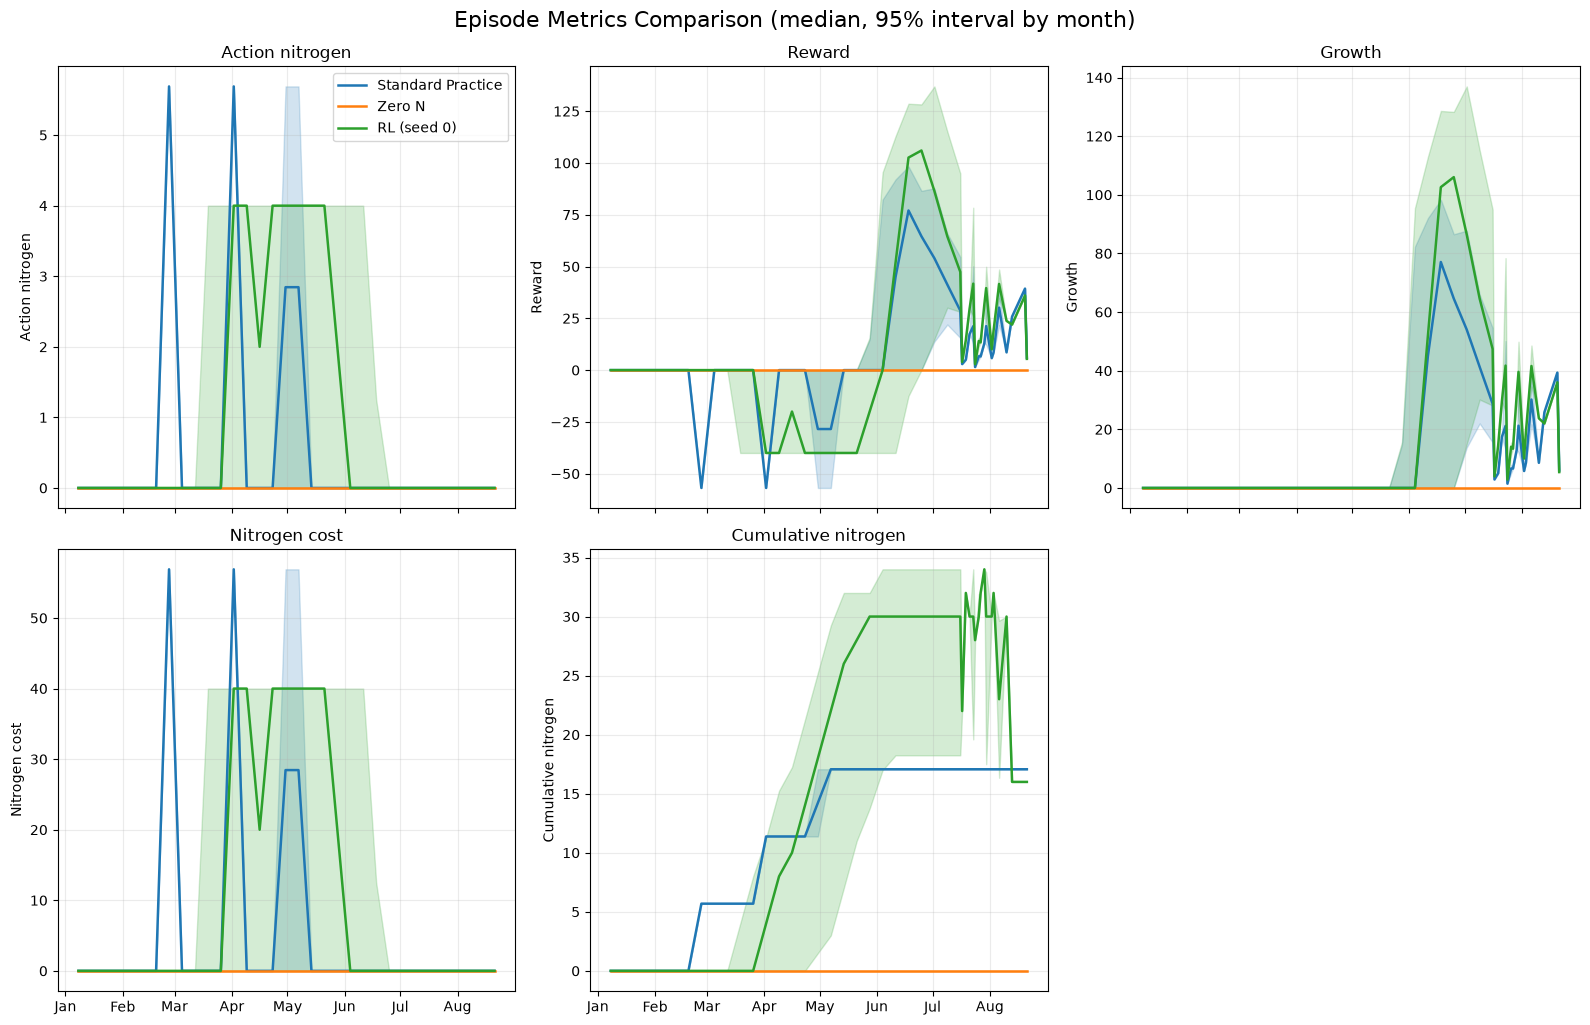

In [18]:
monthly_results = {
    "Standard Practice": [result.history for result in sp_results_north],
    "Zero N": [result.history for result in zero_results_north],
    "RL (seed 0)": [result.history for result in rl_results_north[0]],
}
plot_complete_comparison_monthly(monthly_results)